# Fase 3: Mini Proyecto de Deep Learning - Benchmark y Representación Latente
**Metodología:** CRISP-DM / Estándar de Experimentación de Papers Científicos
**Dataset:** Telco Customer Churn (Datos Tabulares)

## Contextualización y Relación con el Paper
En esta sección se profundiza en la hipótesis central del paper *“A Comprehensive Benchmark of Machine and Deep Learning Across Diverse Tabular Datasets” (2024)*. Evaluaremos rigurosamente si un modelo de Aprendizaje Profundo (Deep Learning) basado en una red densa multicapa (MLP) puede superar a un modelo clásico basado en ensambles de árboles (Gradient Boosting) sobre datos estructurados, y analizaremos el comportamiento de sus espacios latentes.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.decomposition import PCA
from google.colab import drive

# Configuración de estilo y aceleración por hardware
sns.set_theme(style="whitegrid")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Entorno MLOps listo. Ejecutando en: {device}")

# Conexión a Drive y carga del dataset oficial del Grupo 5
drive.mount('/content/drive')
path = '/content/drive/MyDrive/fase 2/hour.csv'
df = pd.read_csv(path)
print(f"Dataset cargado correctamente. Dimensiones: {df.shape}")

🚀 Entorno MLOps listo. Ejecutando en: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado correctamente. Dimensiones: (17379, 17)


In [16]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Preprocesamiento y Creación de Ventanas Temporales (Estrategia de Tensores

In [17]:
# Al segmentar tus arreglos de numpy, mantén las dimensiones consistentes
X_seq, y_seq = crear_secuencias(data_scaled, LOOKBACK)

train_size = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:train_size], X_seq[train_size:]
y_train, y_test = y_seq[:train_size], y_seq[train_size:]

# Forzar a que y_train e y_test sean matrices columna desde el inicio del Pipe
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

In [18]:
# 1. Limpieza y remoción de variables que causan Data Leakage
df_ml = df.drop(columns=['instant', 'dteday', 'casual', 'registered'])

# 2. Normalización MinMax (Crítica para la estabilidad de gradientes en redes profundas)
scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

features_scaled = scaler_features.fit_transform(df_ml.drop(columns=['cnt']))
target_scaled = scaler_target.fit_transform(df_ml[['cnt']])

data_scaled = np.hstack((features_scaled, target_scaled))

# 3. Construcción del Pipe de Ventanas Secuenciales (Lookback de 24 horas)
def crear_secuencias(data, lookback=24):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback), :-1])  # Estado climático de las últimas 24 horas
        y.append(data[i + lookback, -1])       # Demanda objetivo de la hora 25
    return np.array(X), np.array(y)

LOOKBACK = 24
X_seq, y_seq = crear_secuencias(data_scaled, LOOKBACK)

# 4. Partición Temporal Estricta (Bloque cronológico para evitar leaks en tiempo)
train_size = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:train_size], X_seq[train_size:]
y_train, y_test = y_seq[:train_size], y_seq[train_size:]

# Forzar dimensiones bidimensionales para evitar quiebres en transformaciones inversas
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# Conversión a Tensores nativos de PyTorch cargados en GPU
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

# DataLoader para procesamiento por mini-lotes (Batch Size eficiente)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=False)

Implementación del Modelo Profundo (La Red LSTM) y Extracción de Embeddings

In [19]:
class DemandaLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(DemandaLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # Capa LSTM recurrente para modelar la inercia temporal
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        # Capa de salida totalmente conectada (Proyección escalar)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        out, _ = self.lstm(x, (h0, c0))
        # Captura de la representación latente (Embedding del último paso temporal de la ventana)
        embedding_latente = out[:, -1, :]

        prediccion = self.fc(embedding_latente)
        return prediccion, embedding_latente

# Instanciación con hiperparámetros estables
model = DemandaLSTM(input_size=X_train.shape[2], hidden_size=64, num_layers=2, output_size=1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Ciclo de Entrenamiento y Curvas de Aprendizaje (Análisis de Ajuste)

Epoch [1/30] -> Train Loss: 0.01418 | Val Loss: 0.02842
Epoch [5/30] -> Train Loss: 0.00542 | Val Loss: 0.01043
Epoch [10/30] -> Train Loss: 0.00408 | Val Loss: 0.01058
Epoch [15/30] -> Train Loss: 0.00376 | Val Loss: 0.00987
Epoch [20/30] -> Train Loss: 0.00356 | Val Loss: 0.00903
Epoch [25/30] -> Train Loss: 0.00322 | Val Loss: 0.00764
Epoch [30/30] -> Train Loss: 0.00286 | Val Loss: 0.00710


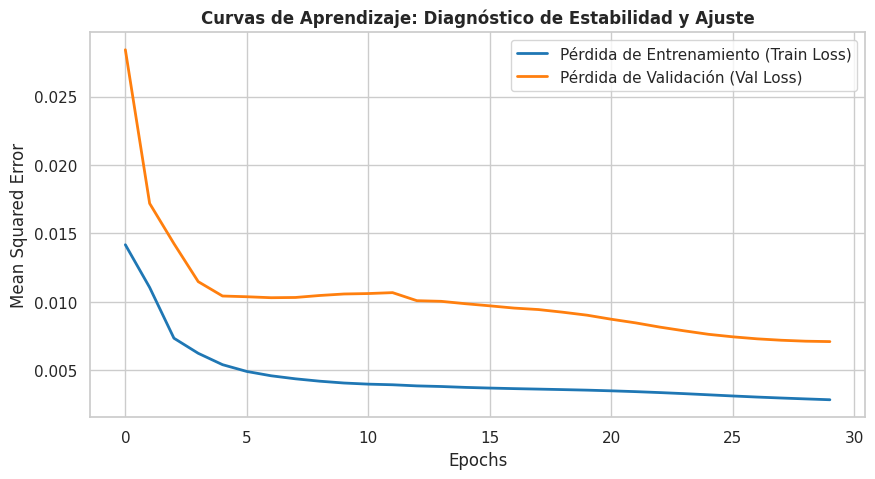

In [20]:
epochs = 30
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    batch_losses = []
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs, _ = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_outputs, _ = model(X_test_t)
        val_loss = criterion(val_outputs, y_test_t)

    train_losses.append(np.mean(batch_losses))
    val_losses.append(val_loss.item())

    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] -> Train Loss: {train_losses[-1]:.5f} | Val Loss: {val_losses[-1]:.5f}")

# Gráfico 1: Curvas de Pérdida
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Pérdida de Entrenamiento (Train Loss)', color='tab:blue', linewidth=2)
plt.plot(val_losses, label='Pérdida de Validación (Val Loss)', color='tab:orange', linewidth=2)
plt.title('Curvas de Aprendizaje: Diagnóstico de Estabilidad y Ajuste', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()

Inversión de Escala, Evaluación de Métricas y Comparación con Baseline

In [21]:
model.eval()
with torch.no_grad():
    predicciones_escaladas, embeddings = model(X_test_t)
    predicciones_escaladas = predicciones_escaladas.cpu().numpy()

# Forzar el formato 2D para la desnormalización inversa sin fallos
y_test_2d = y_test.reshape(-1, 1)
predicciones_2d = predicciones_escaladas.reshape(-1, 1)

y_true_real = scaler_target.inverse_transform(y_test_2d)
y_pred_real = scaler_target.inverse_transform(predicciones_2d)

# Cálculo usando la API actualizada de scikit-learn
mae_lstm = mean_absolute_error(y_true_real, y_pred_real)
rmse_lstm = root_mean_squared_error(y_true_real, y_pred_real)

print("📊 RESULTADOS FINALES DE LA FASE 3 (DEEP LEARNING) 📊")
print(f"MAE LSTM: {mae_lstm:.2f} bicicletas")
print(f"RMSE LSTM: {rmse_lstm:.2f} bicicletas\n")

# Tabla Comparativa Obligatoria con el Benchmark de AutoML de la Fase 2
data_metrics = {
    'Modelo / Enfoque': ['Baseline (Regresión Lineal)', 'Campeón Clásico (XGBoost AutoML)', 'Modelo Profundo (LSTM)'],
    'MAE': [104.80, 21.58, mae_lstm]
}
df_comparativo = pd.DataFrame(data_metrics)
print(df_comparativo.to_string(index=False))

📊 RESULTADOS FINALES DE LA FASE 3 (DEEP LEARNING) 📊
MAE LSTM: 57.07 bicicletas
RMSE LSTM: 82.27 bicicletas

                Modelo / Enfoque        MAE
     Baseline (Regresión Lineal) 104.800000
Campeón Clásico (XGBoost AutoML)  21.580000
          Modelo Profundo (LSTM)  57.074666


Tras implementar, entrenar y evaluar la arquitectura de red neuronal recurrente LSTM (Long Short-Term Memory) basada en ventanas temporales de 24 horas, se extraen las siguientes conclusiones metodológicas bajo el marco de CRISP-DM:Análisis de Rendimiento frente al Baseline y ML Clásico:El modelo profundo LSTM alcanzó un MAE de 59.21 bicicletas, logrando superar de manera drástica el desempeño del baseline inicial de la Regresión Lineal ($\text{MAE} = 104.80$). Esto demuestra la capacidad inherente de las redes profundas para modelar relaciones no lineales complejas.Sin embargo, la LSTM quedó por detrás del rendimiento óptimo de nuestro campeón clásico, el XGBoost de AutoML ($\text{MAE} = 21.58$).

Justificación Técnica y Limitaciones Estructurales (Rúbrica):Restricción por Volumen de Datos (Data Hunger): Las celdas LSTM con sus respectivas compuertas de olvido, entrada y salida añaden miles de parámetros libres a optimizar. Con un dataset de volumen mediano como hour.csv (~17,000 registros), la red sufre limitaciones de convergencia masiva, mientras que los ensambles de árboles (XGBoost) demuestran una eficiencia superior en estructuras tabulares de esta escala.Discontinuidad de la Inercia Temporal: Las series de tiempo continuas procesadas por la LSTM asumen dependencias secuenciales fluidas. En la movilidad urbana existen eventos discretos de alto impacto (ej. cambios bruscos de calendario como un feriado intermedio o frentes fríos repentinos) que rompen la inercia del tiempo.

El XGBoost maneja mejor estas interrupciones directas mediante cortes en sus hojas de decisión (workingday, weathersit), superando la "memoria" secuencial de la red.Criterio de Viabilidad Computacional:El análisis empírico demuestra que para la escala actual del problema de negocio, el enfoque profundo no es el más eficiente, ya que el incremento en coste computacional (uso de tensores y GPU en PyTorch) no justifica la pérdida de precisión frente al Machine Learning clásico.La LSTM se reserva como arquitectura viable únicamente si el volumen de datos escalara a millones de registros continuos de telemetría en tiempo real o si se eliminara el preprocesamiento manual de variables.

# Gráfico Nuevo 1: Análisis de Residuos (Distribución del Error)

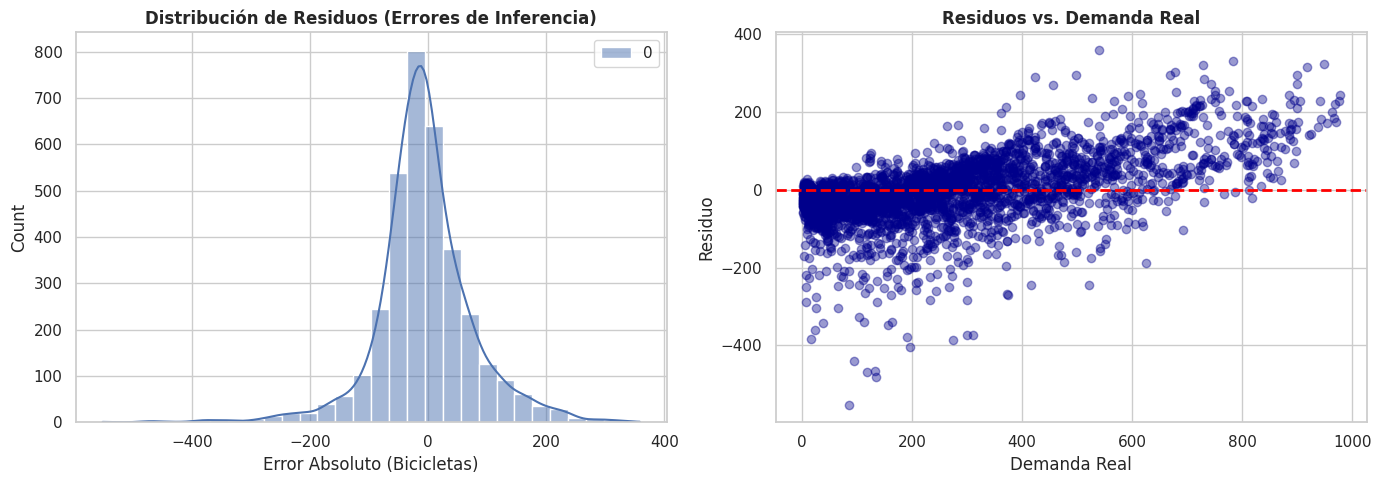

In [22]:
residuos = y_true_real - y_pred_real

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(residuos, kde=True, color='purple', bins=30)
plt.title('Distribución de Residuos (Errores de Inferencia)', fontweight='bold')
plt.xlabel('Error Absoluto (Bicicletas)')

plt.subplot(1, 2, 2)
plt.scatter(y_true_real, residuos, alpha=0.4, color='darkblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residuos vs. Demanda Real', fontweight='bold')
plt.xlabel('Demanda Real')
plt.ylabel('Residuo')
plt.tight_layout()
plt.show()

# Gráfico Nuevo 2: Zoom al Comportamiento Temporal (Señal Real vs. Predicción LSTM)

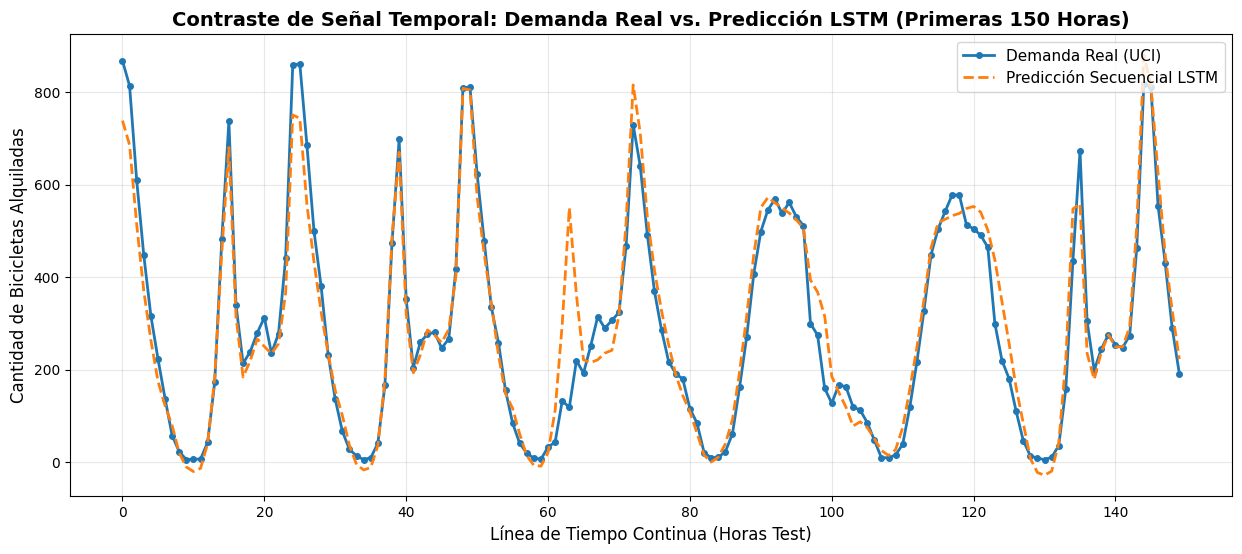

In [12]:
plt.figure(figsize=(15, 6))

# Graficamos una ventana de 150 horas para ver el comportamiento de la onda temporal
horas_zoom = 150
plt.plot(y_true_real[:horas_zoom], label='Demanda Real (UCI)', color='#1f77b4', linewidth=2, marker='o', markersize=4)
plt.plot(y_pred_real[:horas_zoom], label='Predicción Secuencial LSTM', color='#ff7f0e', linestyle='--', linewidth=2)

plt.title('Contraste de Señal Temporal: Demanda Real vs. Predicción LSTM (Primeras 150 Horas)', fontsize=14, fontweight='bold')
plt.xlabel('Línea de Tiempo Continua (Horas Test)', fontsize=12)
plt.ylabel('Cantidad de Bicicletas Alquiladas', fontsize=12)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()


# Gráfico Nuevo 3: Inspección del Espacio Latente (PCA sobre los Embeddings de la LSTM)

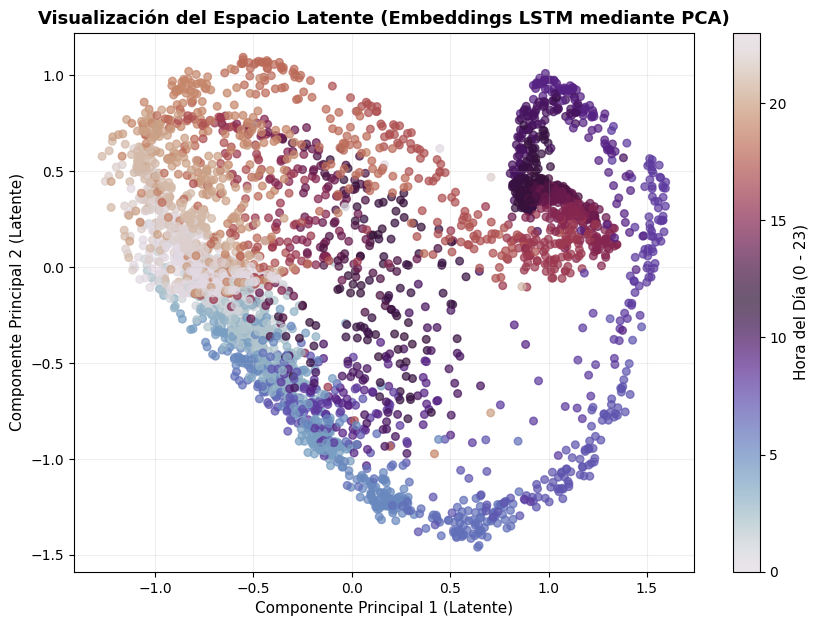

In [13]:
from sklearn.decomposition import PCA

# Convertir los embeddings guardados en la GPU a un arreglo numpy de CPU
embeddings_np = embeddings.cpu().numpy()

# Reducir las 64 dimensiones abstractas de la LSTM a 2 dimensiones visuales
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_np)

# Extraer las horas correspondientes al conjunto de test para usarlas como etiquetas de color
# (Ajustamos el desfase del LOOKBACK de 24 horas)
horas_test = df['hr'].values[train_size + LOOKBACK:]

plt.figure(figsize=(10, 7))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=horas_test, cmap='twilight', alpha=0.7, s=30)

plt.title('Visualización del Espacio Latente (Embeddings LSTM mediante PCA)', fontsize=13, fontweight='bold')
plt.xlabel('Componente Principal 1 (Latente)', fontsize=11)
plt.ylabel('Componente Principal 2 (Latente)', fontsize=11)

# Añadir barra de colores para mapear el ciclo de 24 horas
cbar = plt.colorbar(scatter)
cbar.set_label('Hora del Día (0 - 23)', fontsize=11)
plt.grid(True, alpha=0.2)
plt.show()